<a href="https://colab.research.google.com/github/Karsuman4298/Machine_learning/blob/main/Kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [149]:
import pandas as pd


In [150]:
df=pd.read_csv("new.csv")

In [151]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [152]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [153]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [154]:
df=df.backfill()

/tmp/ipykernel_8783/1688842819.py:1: FutureWarning: DataFrame.backfill/Series.backfill is deprecated. Use DataFrame.bfill/Series.bfill instead
  df=df.backfill()


In [155]:

df = df.drop(['Education', 'Marital_Status'], axis=1, errors='ignore')

import numpy as np
df['Age'] = 2026 - df['Year_Birth']
df['TotalSpending'] = df[['MntWines','MntFruits','MntMeatProducts',
                          'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['TotalPurchases'] = df[['NumDealsPurchases','NumWebPurchases',
                           'NumCatalogPurchases','NumStorePurchases']].sum(axis=1)
df['Children'] = df['Kidhome'] + df['Teenhome']


X = df.select_dtypes(include=[np.number]).copy()

print("Features used:", X.columns.tolist())
print("Shape:", X.shape)

Features used: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'TotalSpending', 'TotalPurchases', 'Children']
Shape: (2240, 30)


Distortion values:
1 : 632260025.230977
2 : 463600885.8447476
3 : 220980387.67127785
4 : 119918925.98361824
5 : 61901291.552894905
6 : 36729742.95268889
7 : 24380427.707459703
8 : 18291870.097066127
9 : 14391572.76604423


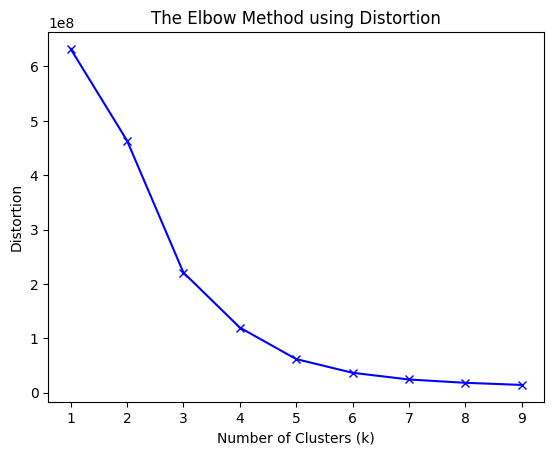

In [156]:
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

In [157]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K =  2 → Silhouette Score = 0.2582
K =  3 → Silhouette Score = 0.1931
K =  4 → Silhouette Score = 0.1913
K =  5 → Silhouette Score = 0.1288
K =  6 → Silhouette Score = 0.1362
K =  7 → Silhouette Score = 0.1385
K =  8 → Silhouette Score = 0.1367
K =  9 → Silhouette Score = 0.1353
K = 10 → Silhouette Score = 0.1376


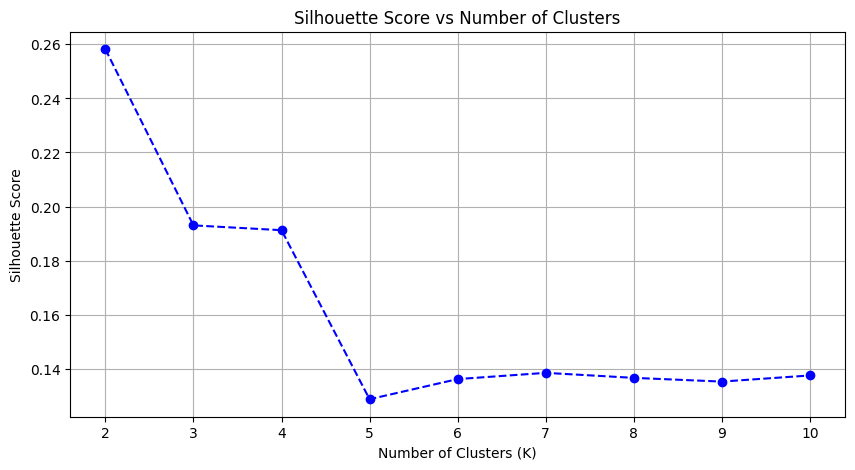


 BEST K = 2 with Silhouette Score = 0.2582


In [158]:
silhouette_scores = []
K_range = range(2, 11)
best_k = 2
best_score = -1


from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_scaled_imputed = imputer.fit_transform(X_scaled)

for k in K_range:
    kmeans = KMeans(n_clusters=k,
                    init='k-means++',
                    n_init=10,
                    random_state=42)

    labels = kmeans.fit_predict(X_scaled_imputed)
    score = silhouette_score(X_scaled_imputed, labels)
    silhouette_scores.append(score)

    print(f"K = {k:2d} → Silhouette Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

print(f"\n BEST K = {best_k} with Silhouette Score = {best_score:.4f}")

In [171]:

final_kmeans = KMeans(n_clusters=best_k,
                      init='k-means++',
                      n_init=10,
                      random_state=42)
df['Cluster'] = final_kmeans.fit_predict(X_scaled_imputed)

final_score = silhouette_score(X_scaled_imputed, df['Cluster'])
print(f"\n FINAL SILHOUETTE SCORE: {final_score:.4f}")
print("\nCluster distribution:\n", df['Cluster'].value_counts().sort_index())


 FINAL SILHOUETTE SCORE: 0.2582

Cluster distribution:
 Cluster
0    1310
1     930
Name: count, dtype: int64


In [172]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_scaled = pca.fit_transform(X_scaled)

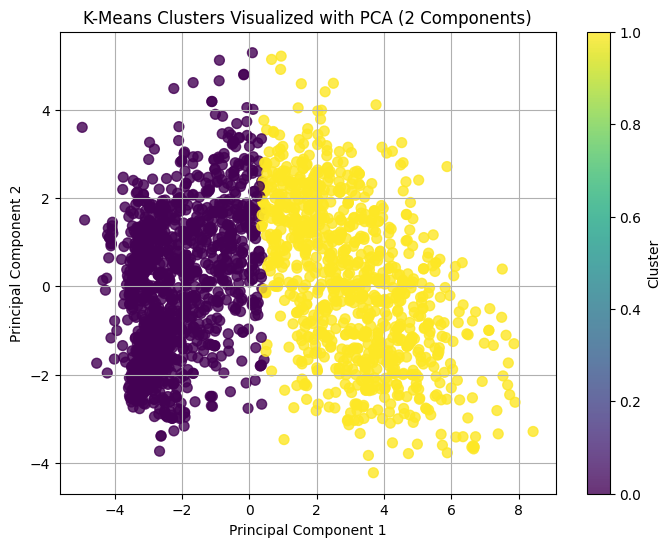

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster'], cmap='viridis', s=50, alpha=0.8)
plt.title('K-Means Clusters Visualized with PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

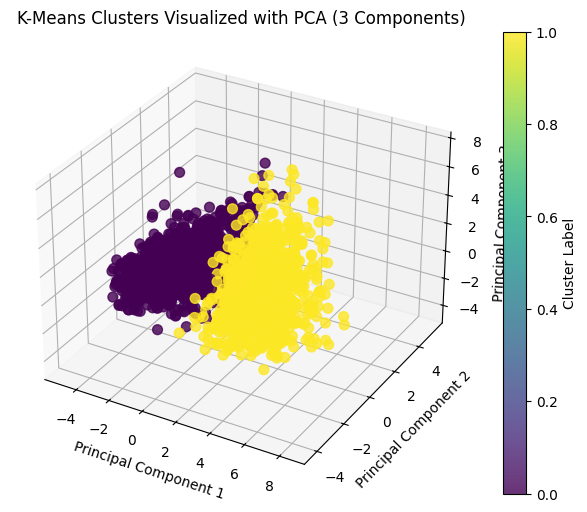

In [178]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=df['Cluster'], cmap='viridis', s=50, alpha=0.8)

ax.set_title('K-Means Clusters Visualized with PCA (3 Components)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Cluster Label')

plt.grid(True)
plt.show()

In [176]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])

print(f"The silhouette score for the clustering is: {silhouette_avg:.4f}")

The silhouette score for the clustering is: 0.4511
